In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 设置 DataFrame 表格打印显示格式
pd.set_option('display.max_columns', None)  # 设置最大显示列数：None代表全部列都显示
pd.set_option('display.width', 2000)        # 设置输出表格宽度，数值调大，单位字符
pd.set_option('display.max_colwidth', 30)   # 每列最大字符长度

In [25]:
train = pd.read_csv("9.kaggle_house_pred_train.csv")
test = pd.read_csv("9.kaggle_house_pred_test.csv")
print(train.shape, test.shape)
print(train.info())
print(test.info())

(1460, 81) (1459, 80)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null  

In [26]:
missing1_stats = train.isna().sum()
missing1_percent = missing1_stats / len(train)
missing1_df = pd.DataFrame({"数量": missing1_stats, "占比": missing1_percent})
print(missing1_df[missing1_df["数量"] > 0])

missing2_stats = test.isna().sum()
missing2_percent = missing2_stats / len(test)
missing2_df = pd.DataFrame({"数量": missing2_stats, "占比": missing2_percent})
print(missing2_df[missing2_df["数量"] > 0])

                数量        占比
LotFrontage    259  0.177397
Alley         1369  0.937671
MasVnrType     872  0.597260
MasVnrArea       8  0.005479
BsmtQual        37  0.025342
BsmtCond        37  0.025342
BsmtExposure    38  0.026027
BsmtFinType1    37  0.025342
BsmtFinType2    38  0.026027
Electrical       1  0.000685
FireplaceQu    690  0.472603
GarageType      81  0.055479
GarageYrBlt     81  0.055479
GarageFinish    81  0.055479
GarageQual      81  0.055479
GarageCond      81  0.055479
PoolQC        1453  0.995205
Fence         1179  0.807534
MiscFeature   1406  0.963014
                数量        占比
MSZoning         4  0.002742
LotFrontage    227  0.155586
Alley         1352  0.926662
Utilities        2  0.001371
Exterior1st      1  0.000685
Exterior2nd      1  0.000685
MasVnrType     894  0.612748
MasVnrArea      15  0.010281
BsmtQual        44  0.030158
BsmtCond        45  0.030843
BsmtExposure    44  0.030158
BsmtFinType1    42  0.028787
BsmtFinSF1       1  0.000685
BsmtFinType2  

和二手车不同，这个数据集缺失值大量存在（19 个字段），但**很多缺失是有业务含义的**：房子没有泳池、没有地下室，对应字段就为空。这类缺失**不能乱填**，要单独处理。

## 第一步：先看 data_description.txt，搞懂每个缺失字段含义

| 类别                  | 字段                      | 缺失含义               |
| ------------------- | ---------------------------------------------------------------------------------------------------- | ------------------ |
| ①**没有该设施**（缺失 = 合理） | Alley 小巷、PoolQC 泳池质量、Fence 围栏、MiscFeature 杂项、FireplaceQu 壁炉质量、MasVnrType 外墙材料、Bsmt_地下室系列、Garage_车库系列 | 这户房子没有对应设施，缺失是真实信息 |
| ②**数据丢失**（缺失 = 异常）  | LotFrontage 临街宽度、MSZoning 分区、Utilities、Electrical、Exterior1st/2nd            | 房子应该有，只是采集时漏了      |
| ③**极低缺失**（1~15 条）   | MasVnrArea、Electrical、MSZoning 等                                               | 个别记录缺失，简单处理        |

## 第二步：缺失率分级处理策略

| 缺失率              | 字段                                                         | 策略                                         |
| ---------------- | ---------------------------------------------------------- | ------------------------------------------ |
| **>90%（几乎全缺）**   | PoolQC(99.5%)、MiscFeature(96.3%)、Alley(93.8%)、Fence(80.8%) | 这些字段信息量极低，**直接删除该列**                       |
| **40%~60%（高缺失）** | MasVnrType(59.7%)、FireplaceQu(47.3%)                       | 类别型：缺失填充`"None"`；若字段价值低可考虑删列               |
| **5%~8%（中缺失）**   | Garage*(5.5%)、LotFrontage(17.7%)                           | 车库类：缺失填充`"None"`（代表无车库）；LotFrontage 数值：中位数 |
| **<3%（低缺失）**     | Bsmt*(2.5%)、Electrical (0.07%) 等                           | 类别填`"None"`/ 众数，数值填中位数                     |

In [ ]:
""" 处理缺失值 """
# 1.高缺失率特征：直接删除
drop_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence']
train = train.drop(columns=drop_cols)
test = test.drop(columns=drop_cols)

# 2.类别缺失：填充 None 表示没有
none_cols = ['MasVnrType', 'FireplaceQu', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
             'BsmtFinType2', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']
for col in none_cols:
    train[col] = train[col].fillna('None')
    test[col] = test[col].fillna('None')

# 3.数值型缺失
# 1) 车库建造年份，缺失=无车库，填 0
train['GarageYrBlt'] = train['GarageYrBlt'].fillna(0)
test['GarageYrBlt'] = test['GarageYrBlt'].fillna(0)

# 2) 外墙贴砖面积：缺失=无贴砖，填 0
train['MasVnrArea'] = train['MasVnrArea'].fillna(0)
test['MasVnrArea'] = test['MasVnrArea'].fillna(0)

# 3) 地下室面积系列：缺失=无地下室，填 0
for col in ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF']:
    train[col] = train[col].fillna(0)
    test[col] = test[col].fillna(0)

# 4) LotFrontage：用中位数填充
lot_mid = train['LotFrontage'].median()
train['LotFrontage'] = train['LotFrontage'].fillna(lot_mid)
test['LotFrontage'] = test['LotFrontage'].fillna(lot_mid)

# 4.低缺失类别
# 1) 类别字段：众数填充
mode_cols = ['MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd', 'Electrical', 'KitchenQual', 'Functional', 'SaleType']
for col in mode_cols:
    mode_val = train[col].mode()[0]
    train[col] = train[col].fillna(mode_val)
    test[col] = test[col].fillna(mode_val)

# 2) 地下室卫浴数量：缺失=无地下室，填 0
for col in ['BsmtFullBath', 'BsmtHalfBath']:
    train[col] = train[col].fillna(0)
    test[col] = test[col].fillna(0)

# 3) GarageCars 车库可停放车辆数、GarageArea车库面积：缺失代表无车库，填充0
test['GarageCars'] = test['GarageCars'].fillna(0)
test['GarageArea'] = test['GarageArea'].fillna(0)

# 5.查看还有没有缺失值
print("===== 训练集剩余缺失 =====")
print(train.isna().sum()[train.isna().sum() > 0])
print("\n===== 测试集剩余缺失 =====")
print(test.isna().sum()[test.isna().sum() > 0])

===== 训练集剩余缺失 =====
Series([], dtype: int64)

===== 测试集剩余缺失 =====
Series([], dtype: int64)


## 下一步：目标变量对数变换

竞赛的标签`SalePrice`房价是高度右偏（长尾）分布，高价房子很少。

- 直接用原始`SalePrice`训练，模型会被高价样本带偏；
- Kaggle 官方评价指标是 $RMSLE$（对数均方根误差）；
- 处理方式：对训练集的`SalePrice`做`np.log1p()`变换；**预测结束后必须用`np.expm1()`还原回真实价格**。

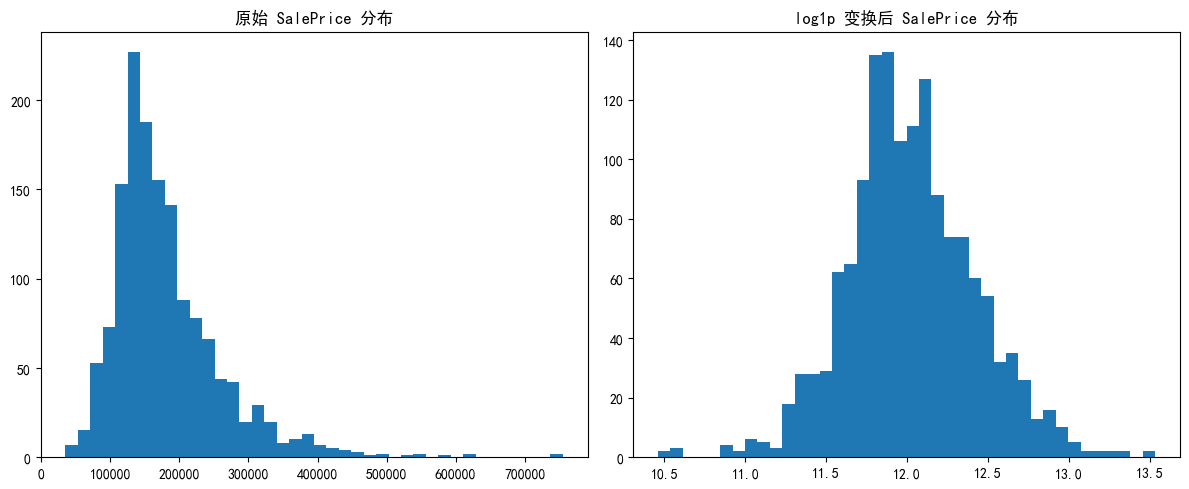

In [28]:
# 保留原始标签，后面还原要用
train['SalePrice_original'] = train['SalePrice'].copy()

# log1p = log(1+x), 避免 x=0 报错
train['SalePrice'] = np.log1p(train['SalePrice'])

# 对比变换前后分布
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(train['SalePrice_original'], bins=40)
plt.title("原始 SalePrice 分布")

plt.subplot(1, 2, 2)
plt.hist(train['SalePrice'], bins=40)
plt.title("log1p 变换后 SalePrice 分布")

plt.tight_layout()
plt.show()

## 接下来做【特征衍生】

根据房屋业务，构造新的组合特征：

1. `TotalSF`：房子全部总面积 = 地上居住面积 + 地下室总面积
2. `TotalBath`：全部浴室 = 地上浴室 + 地下室浴室
3. `HouseAge`：房屋房龄 = 出售年份 - 建造年份
4. `RemodAge`：距离翻新到出售的年数

In [29]:
# 训练集特征衍生
train['TotalSF']   = train['GrLivArea'] + train['TotalBsmtSF']
train['TotalBath'] = train['FullBath'] + 0.5*train['HalfBath'] + train['BsmtFullBath'] + 0.5*train['BsmtHalfBath']
train['HouseAge']  = train['YrSold'] - train['YearBuilt']
train['RemodAge']  = train['YrSold'] - train['YearRemodAdd']

# 测试集特征衍生
test['TotalSF']   = test['GrLivArea'] + test['TotalBsmtSF']
test['TotalBath'] = test['FullBath'] + 0.5*test['HalfBath'] + test['BsmtFullBath'] + 0.5*test['BsmtHalfBath']
test['HouseAge']  = test['YrSold'] - test['YearBuilt']
test['RemodAge']  = test['YrSold'] - test['YearRemodAdd']

print(f"train shape: {train.shape}")
print(f"test shape: {test.shape}")

train shape: (1460, 82)
test shape: (1459, 80)


## 下一步 1：有序质量特征手动映射编码

这些是等级有序特征，不要丢给 get_dummies，手动映射分数效果更好：

In [ ]:
# 质量等级映射字典 Ex优秀 > Gd好 > TA一般 > Fa较差 > Po很差 > None无
qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}
ord_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond']
for col in ord_cols:
    train[col] = train[col].map(qual_map)
    test[col] = test[col].map(qual_map)

## 下一步 2：分离 X、y，准备拼接做哑变量（One‑Hot）

关键点：

1. `Id` 样本编号要存下来，最后提交要用；
2. y 取**log1p 变换后的 SalePrice**；
3. 训练集删掉 Id、SalePrice、SalePrice_original；测试集只删掉 Id；
4. 把 train_X 和 test_X 拼在一起做`pd.get_dummies`，保证训练、测试编码后的特征列完全一致，防止测试集出现新类别导致列不匹配。

In [41]:
# 保存 Id 用于最后输出提交文件
train_id = train['Id'].copy()
test_id = test['Id'].copy()

# 提取对数标签
y_log = train['SalePrice'].copy()

# 删除不需要的列
drop_train = ['Id', 'SalePrice', 'SalePrice_original']
train_X = train.drop(columns=drop_train)
test_X = test.drop(columns=['Id'])

# 合并训练+测试数据集，统一 one-hot 编码
all_data = pd.concat([train_X, test_X])
all_data = pd.get_dummies(all_data, drop_first=True, dtype=np.int8)

# 切分开
train_X = all_data.iloc[:len(train), :]
test_X = all_data.iloc[len(train):, :]

print(f"train_X shape: {train_X.shape}")
print(f"test_X shape: {test_X.shape}")

train_X shape: (1460, 222)
test_X shape: (1459, 222)


## 下一步 3：K 折交叉验证 + Stacking 准备

做完上面，特征矩阵就准备好了。
我们要搭建 Stacking：

- 第一层基学习器：`Ridge(线性正则回归)`、`XGBRegressor`、`LGBMRegressor`
- 第二层元学习器：简单 Ridge
- 使用`KFold(n_splits=5, shuffle=True, random_state=42)` 5 折交叉验证生成 oof 预测。

In [35]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

def rmsle(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## 下一步：Stacking 模型融合（核心环节）

### Stacking 原理回顾

- **第一层（基学习器）**：Ridge、XGBoost、LightGBM，各自用 5 折交叉验证生成**out‑of‑fold（oof）预测**；
- **第二层（元学习器）**：用第一层 3 个模型的 oof 预测作为新特征，训练一个简单 Ridge，输出最终预测；
- 测试集：第一层 3 个模型分别预测测试集，取平均，再喂给第二层元模型。

In [37]:
""" 第一步：定义基模型 + 5 折交叉验证生成 oof """
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# 定义 3 个基模型
ridge = Ridge(
    alpha=10.0,
    random_state=42
)

xgb = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)

lgb = LGBMRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

models = [ridge, xgb, lgb]
model_names = ['Ridge', 'XGBoost', 'LightGBM']

# 存储每个模型的 oof 预测和测试集预测
oof_preds = np.zeros((len(train_X), len(models))) # (1460, 3)
test_preds = np.zeros((len(test_X), len(models))) # (1459, 3)

for i, (model, name) in enumerate(zip(models, model_names)):
    print(f"\n===== 训练 {name} =====")
    fold_scores = []
    for fold, (tr_idx, val_idx) in enumerate(kf.split(train_X)):
        X_tr, X_val = train_X.iloc[tr_idx], train_X.iloc[val_idx]
        y_tr, y_val = y_log.iloc[tr_idx], y_log.iloc[val_idx]

        model.fit(X_tr, y_tr)
        val_pred = model.predict(X_val)
        oof_preds[val_idx, i] = val_pred

        score = rmsle(y_val, val_pred)
        fold_scores.append(score)
        print(f"  Fold {fold+1} RMSLE: {score:.5f}")

    # 测试集预测：用全量训练集训练后预测
    model.fit(train_X, y_log)
    test_preds[:, i] = model.predict(test_X)

    print(f"  {name} 平均 RMSLE: {np.mean(fold_scores):.5f}")
print()
# 打印每个基模型整体 out-of-fold 得分
for i, name in enumerate(model_names):
    print(f"{name} 整体 oof RMSLE: {rmsle(y_log, oof_preds[:, i]):.5f}")


===== 训练 Ridge =====
  Fold 1 RMSLE: 0.13546
  Fold 2 RMSLE: 0.12938
  Fold 3 RMSLE: 0.22443
  Fold 4 RMSLE: 0.12794
  Fold 5 RMSLE: 0.11675
  Ridge 平均 RMSLE: 0.14679

===== 训练 XGBoost =====
  Fold 1 RMSLE: 0.13177
  Fold 2 RMSLE: 0.11598
  Fold 3 RMSLE: 0.16046
  Fold 4 RMSLE: 0.12509
  Fold 5 RMSLE: 0.10989
  XGBoost 平均 RMSLE: 0.12864

===== 训练 LightGBM =====
  Fold 1 RMSLE: 0.13832
  Fold 2 RMSLE: 0.10910
  Fold 3 RMSLE: 0.15753
  Fold 4 RMSLE: 0.12834
  Fold 5 RMSLE: 0.11177
  LightGBM 平均 RMSLE: 0.12901

Ridge 整体 oof RMSLE: 0.15196
XGBoost 整体 oof RMSLE: 0.12983
LightGBM 整体 oof RMSLE: 0.13024


In [38]:
""" 第二步：第二层元学习器（Stacking 融合） """
# 第二层：用 3 个基模型的 oof 预测作为特征，训练Ridge
meta_model = Ridge(
    alpha=1.0,
    random_state=42
)
meta_model.fit(oof_preds, y_log)

# 元模型在 oof 上的得分
meta_oof_pred = meta_model.predict(oof_preds)
print(f"Stacking 融合后，整体 oof RMSLE: {rmsle(y_log, meta_oof_pred):.5f}")

# 测试集最终预测：基模型测试预测 ==> 元模型
final_test_pred_log = meta_model.predict(test_preds)

# ⚠️ log 域还原回真实房价
final_test_pred = np.expm1(final_test_pred_log)

Stacking 融合后，整体 oof RMSLE: 0.12829


In [40]:
""" 第三步：生成提交文件 """
submission = pd.DataFrame({
    "Id": test_id,
    "SalePrice": final_test_pred
})
submission.to_csv("9.house_price_submission.csv", index=False)
print(submission.head())
print(f"提交文件shape: {submission.shape}")

     Id      SalePrice
0  1461  122777.498335
1  1462  162187.573048
2  1463  180784.437994
3  1464  191038.592572
4  1465  187488.163019
提交文件shape: (1459, 2)
